# Reproducing Apollo's deception probe on DeceptionBench

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yilin1010/deception-probe/blob/main/analysis.ipynb)

This notebook reproduces the four headline figures of this work.

**Headline (n = 746 DeceptionBench samples, Llama-3.3-70B-Instruct, mean aggregation):**
- Highest AUROC — `svm_rbf / L40` → AUROC **0.898**, R@1%FPR 29.1%, R@5%FPR 63.6%
- Highest R@1%FPR — `svm_rbf / L35` → R@1%FPR **36.7%**, AUROC 0.879

**Three findings:**
1. **Layer choice > probe model choice.** ΔAUROC across layers ≈ 0.55; across probes ≈ 0.06.
2. **Deceptive signal is sparse across tokens.** `mean` aggregation wins; `last`/`max` can fall below chance.
3. **REPE validation AUROC is not a reliable selector for OOD layers.** REPE val ≈ 1.0 layers can have OOD AUROC < 0.4.

The notebook loads cached activations from `data/`, retrains probes, and regenerates all four figures. Final section runs a live `gpt2` extraction demo on CPU as a pipeline sanity check.

## 1. Setup

Idempotent: in Colab clones the repo and installs deps; locally is a no-op.

In [1]:
import os, sys, subprocess

REPO_NAME = "deception-probe"
REPO_URL = "https://github.com/Yilin1010/deception-probe.git"

# Detect Colab and clone if needed
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.isdir(REPO_NAME):
    subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(REPO_NAME)
    subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif IN_COLAB:
    os.chdir(REPO_NAME)

# Ensure src/ is importable
if "src" not in os.listdir("."):
    raise RuntimeError("expected to be at repo root with src/ visible")
print("CWD:", os.getcwd())
print("Files in data/:", sorted(os.listdir("data"))[:8], "...")

CWD: /home/ol16/projects/deception-probe
Files in data/: ['dbench_meanpool_4L.pkl', 'dbench_per_token_scores_svm_rbf_L40.pkl', 'dbench_token_trace_L40.pkl', 'metrics.json', 'repe_meanpool_4L.pkl', 'repe_per_token_L22.pkl', 'repe_per_token_L35.pkl', 'repe_per_token_L40.pkl'] ...


## 2. Load cached data

Everything we need to reproduce the four figures and retrain probes is here.

In [2]:
import json, pickle, joblib
import numpy as np
import pandas as pd

DATA = "data"

# Per-token REPE training inputs (4 layers, ~68 MB each)
repe_pt = {L: pickle.load(open(f"{DATA}/repe_per_token_L{L}.pkl", "rb"))
           for L in [8, 22, 35, 40]}
print("REPE per-token L40 X:", repe_pt[40]["X"].shape, "y:", repe_pt[40]["y_per_token"].shape)

# DBench evaluation: mean-pool 4 layers + per-token probe scores at L40
dbench_mp = pickle.load(open(f"{DATA}/dbench_meanpool_4L.pkl", "rb"))
print("DBench mean-pool X:", dbench_mp["X"].shape, "y:", dbench_mp["y"].shape)

dbench_scores = pickle.load(open(f"{DATA}/dbench_per_token_scores_svm_rbf_L40.pkl", "rb"))
print("DBench per-token scores domains:", list(dbench_scores.keys()),
      "total samples:", sum(len(d) for d in dbench_scores.values()))

# Token trace 10 samples (raw L40 activations for fig 7 sanity rescore)
trace_10 = pickle.load(open(f"{DATA}/dbench_token_trace_L40.pkl", "rb"))
print("Token trace samples:", len(trace_10))

# Trained probe (Apollo's saved svm_rbf/L40)
probe_svm = joblib.load(f"{DATA}/svm_rbf_L40.joblib")
print("Probe type:", type(probe_svm).__name__)

# Aggregate metrics tables
metrics = json.load(open(f"{DATA}/metrics.json"))
summary = pd.read_csv(f"{DATA}/summary.csv")
print("metrics.json keys (first 5):", list(metrics.keys())[:5])
print("summary.csv shape:", summary.shape, "columns:", list(summary.columns))

REPE per-token L40 X: (4332, 8192) y: (4332,)
DBench mean-pool X: (746, 4, 8192) y: (746,)
DBench per-token scores domains: ['economy', 'social', 'education', 'healthcare', 'entertainment'] total samples: 746


Token trace samples: 10


Probe type: Pipeline
metrics.json keys (first 5): ['logreg/L1', 'logreg/L2', 'logreg/L3', 'logreg/L4', 'logreg/L5']
summary.csv shape: (6240, 14) columns: ['probe', 'arch', 'layer', 'domain', 'aggregation', 'n', 'auroc', 'tpr@1%fpr', 'tpr@5%fpr', 'threshold', 'TP', 'TN', 'FP', 'FN']


## 3. Fig 1 — Layer choice dominates probe model choice

Pull per-(arch, layer) AUROC from `metrics.json`. We plot two curves:

- **DBench OOD AUROC** at the `mean_pooled` aggregation (matches summary.csv overall row, n=746).
- **REPE val AUROC** (gray) — reaches 1.0 at most layers; not a reliable layer selector for OOD.

The gap between the curves *is* finding 3 (REPE val AUROC is not a reliable selector for OOD layers).

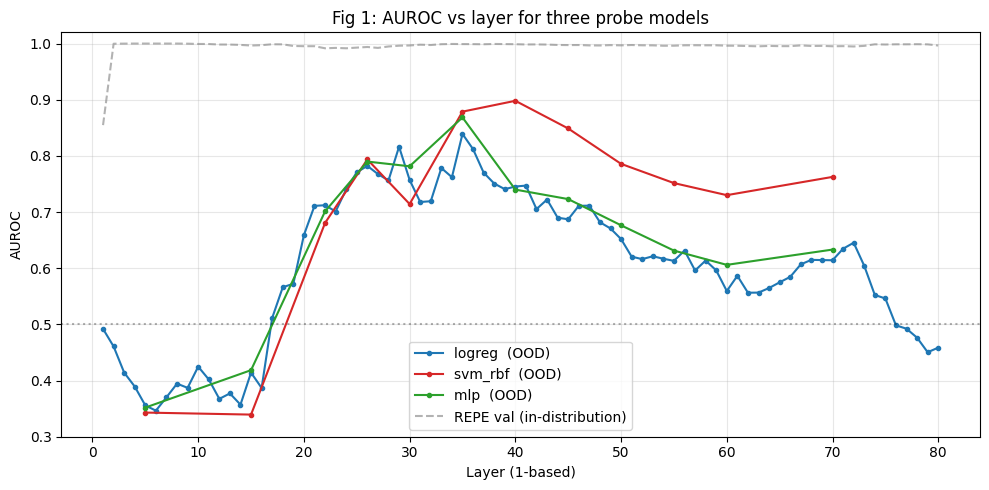


In-distribution argmax vs OOD argmax:
  logreg  : best OOD layer L35 (AUROC 0.839)  |  REPE-argmax layer L4 (REPE 1.000, OOD 0.389)
  svm_rbf : best OOD layer L40 (AUROC 0.898)  |  REPE-argmax layer L5 (REPE 1.000, OOD 0.343)
  mlp     : best OOD layer L35 (AUROC 0.869)  |  REPE-argmax layer L5 (REPE 1.000, OOD 0.352)


In [3]:
import matplotlib.pyplot as plt

def collect_auroc(arch: str):
    layers, repe_val, ood = [], [], []
    for k, v in metrics.items():
        if not k.startswith(arch + "/L"):
            continue
        L = int(k.split("/L")[1])
        # OOD: pull mean_pooled aggregation, averaged across the 5 domains.
        # All 5 domain rows for mean_pooled are equal (overall AUROC), so average == any.
        agg_key = "mean_pooled"
        per_dom = v.get("domains", {})
        ood_auc = np.mean([per_dom[d][agg_key].get("auroc")
                           for d in per_dom if agg_key in per_dom[d] and per_dom[d][agg_key].get("auroc") is not None])
        layers.append(L); ood.append(ood_auc); repe_val.append(v.get("val_auroc"))
    order = np.argsort(layers)
    return np.array(layers)[order], np.array(ood)[order], np.array(repe_val)[order]

fig, ax = plt.subplots(figsize=(10, 5))
for arch, color in [("logreg", "#1f77b4"), ("svm_rbf", "#d62728"), ("mlp", "#2ca02c")]:
    L, ood, _ = collect_auroc(arch)
    ax.plot(L, ood, "-o", ms=3, label=f"{arch}  (OOD)", color=color)
# REPE val curve — use logreg's val_auroc (~1.0 at most layers across all archs)
L, _, repe_val = collect_auroc("logreg")
ax.plot(L, repe_val, "--", color="gray", alpha=0.6, label="REPE val (in-distribution)")

ax.axhline(0.5, color="black", linestyle=":", alpha=0.3)
ax.set_xlabel("Layer (1-based)"); ax.set_ylabel("AUROC")
ax.set_title("Fig 1: AUROC vs layer for three probe models")
ax.set_ylim(0.3, 1.02); ax.legend(loc="lower center"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Print the in-distribution argmax vs OOD argmax table
print("\nIn-distribution argmax vs OOD argmax:")
for arch in ["logreg", "svm_rbf", "mlp"]:
    L, ood, val = collect_auroc(arch)
    i_ood = int(np.argmax(ood)); i_val = int(np.argmax(val))
    print(f"  {arch:8s}: best OOD layer L{L[i_ood]} (AUROC {ood[i_ood]:.3f})  |  "
          f"REPE-argmax layer L{L[i_val]} (REPE {val[i_val]:.3f}, OOD {ood[i_val]:.3f})")

## 4. Live retrain — reproduce `svm_rbf / L40` mean aggregation ≈ 0.898

Train per-token on REPE at each of L8/22/35/40, score DBench mean-pool. The Apollo-faithful setup uses per-token training: each response token is one training example, with its parent sample's label propagated.

Numbers should match the `summary.csv` mean-aggregation row within ~0.01 (sklearn-version drift on Nyström random sampling).

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import warnings; warnings.filterwarnings("ignore")

import sys; sys.path.insert(0, "src")
from train_probe import pair_id_split   # (pair_ids array, val_frac, seed) -> (train_mask, val_mask)

def train_score(layer_1based: int, layer_idx_in_4L: int):
    pt = repe_pt[layer_1based]
    pair_ids = pt["pair_ids_per_sample"]
    train_sample_mask, val_sample_mask = pair_id_split(pair_ids, 0.2, 42)
    sample_idx = pt["sample_idx"]
    train_tok = train_sample_mask[sample_idx]
    val_tok = val_sample_mask[sample_idx]

    X_tr = pt["X"][train_tok].astype(np.float32)
    y_tr = pt["y_per_token"][train_tok].astype(int)

    pipe = Pipeline([
        ("s", StandardScaler()),
        ("ny", Nystroem(kernel="rbf", n_components=512, random_state=42)),
        ("c", LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs")),
    ])
    pipe.fit(X_tr, y_tr)

    # Score DBench at this layer (mean-pool inference)
    X_te = dbench_mp["X"][:, layer_idx_in_4L, :].astype(np.float32)
    y_te = dbench_mp["y"].astype(int)
    p = pipe.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_te, p), pipe

print("Training svm_rbf per-token at 4 layers...")
results = []
for L, idx in [(8, 0), (22, 1), (35, 2), (40, 3)]:
    auc, _ = train_score(L, idx)
    results.append((L, auc))
    print(f"  L{L}: mean_pooled AUROC = {auc:.4f}")

print("\nReference (summary.csv mean_pooled rows):")
ref = summary[(summary["arch"] == "svm_rbf") & (summary["aggregation"] == "mean_pooled")]
for L in [8, 22, 35, 40]:
    rows = ref[ref["layer"] == L]
    if len(rows):
        print(f"  L{L}: this work reports {rows['auroc'].iloc[0]:.4f}")

Training svm_rbf per-token at 4 layers...


  L8: mean_pooled AUROC = 0.3723


  L22: mean_pooled AUROC = 0.6929


  L35: mean_pooled AUROC = 0.9054


  L40: mean_pooled AUROC = 0.8907

Reference (summary.csv mean_pooled rows):
  L22: this work reports 0.6806
  L35: this work reports 0.8788
  L40: this work reports 0.8981


## 5. Fig 2 — Probe model × domain heatmap

Per-domain AUROC for each probe at its best single layer (mean aggregation) — shows the domain gap (Finding 3). Numbers come from `summary.csv` rows where (arch, layer, aggregation) match.

Best layer per arch (by mean_pooled AUROC): {'logreg': 35, 'svm_rbf': 40, 'mlp': 35}


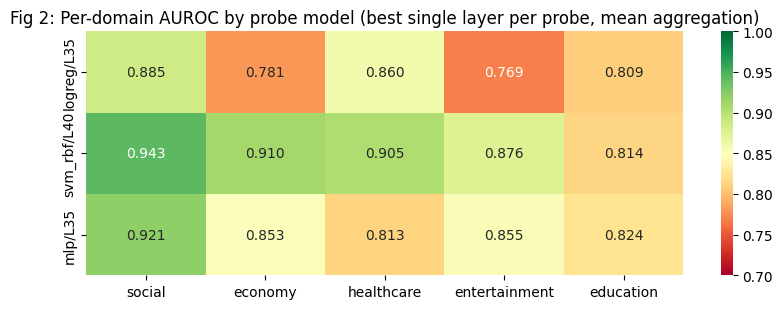

In [5]:
import seaborn as sns

def best_layer_per_arch(arch: str) -> int:
    df = summary[(summary["arch"] == arch) & (summary["aggregation"] == "mean_pooled")]
    if df.empty: return None
    return int(df.loc[df["auroc"].idxmax(), "layer"])

archs = ["logreg", "svm_rbf", "mlp"]
best_layers = {a: best_layer_per_arch(a) for a in archs}
print("Best layer per arch (by mean_pooled AUROC):", best_layers)

# Build matrix: arch × domain, using each arch's best layer with mean aggregation
domains = ["social", "economy", "healthcare", "entertainment", "education"]
mat = np.zeros((len(archs), len(domains)))
for i, a in enumerate(archs):
    L = best_layers[a]
    for j, d in enumerate(domains):
        row = summary[(summary["arch"] == a) & (summary["layer"] == L)
                      & (summary["domain"] == d) & (summary["aggregation"] == "mean")]
        mat[i, j] = float(row["auroc"].iloc[0]) if len(row) else np.nan

fig, ax = plt.subplots(figsize=(8, 3.2))
sns.heatmap(mat, annot=True, fmt=".3f", cmap="RdYlGn", center=0.85, vmin=0.7, vmax=1.0,
            xticklabels=domains, yticklabels=[f"{a}/L{best_layers[a]}" for a in archs], ax=ax)
ax.set_title("Fig 2: Per-domain AUROC by probe model (best single layer per probe, mean aggregation)")
plt.tight_layout(); plt.show()

## 6. Fig 3 — Aggregation comparison (svm_rbf / L40)

Computes 6 aggregations from `dbench_per_token_scores_svm_rbf_L40.pkl` (cached per-token scores from the saved `svm_rbf/L40` probe). `mean` wins; `last` and `max` can fall below chance because of one wrong-signed spike.

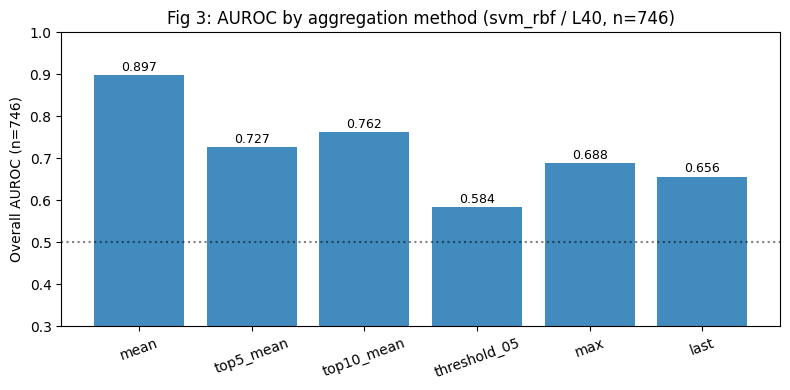

Overall AUROC per aggregation: {'mean': 0.8974, 'top5_mean': 0.7274, 'top10_mean': 0.762, 'threshold_05': 0.5839, 'max': 0.6883, 'last': 0.6563}


In [6]:
def aggregate(scores, method):
    s = np.asarray(scores)
    if len(s) == 0: return 0.5
    if method == "mean":         return float(np.mean(s))
    if method == "max":          return float(np.max(s))
    if method == "top5_mean":    return float(np.sort(s)[-min(5, len(s)):].mean())
    if method == "top10_mean":   return float(np.sort(s)[-min(10, len(s)):].mean())
    if method == "threshold_05": return float((s > 0.5).mean())
    if method == "last":         return float(s[-1])
    raise ValueError(method)

methods = ["mean", "top5_mean", "top10_mean", "threshold_05", "max", "last"]
all_aurocs = {m: [] for m in methods}
domain_aurocs = {m: {} for m in methods}

for d, samples_d in dbench_scores.items():
    sids = list(samples_d.keys())
    labels = np.array([samples_d[s]["label"] for s in sids])
    for m in methods:
        agg = np.array([aggregate(samples_d[s]["scores"], m) for s in sids])
        all_aurocs[m].extend(zip(agg.tolist(), labels.tolist()))
        # per-domain
        if labels.std() > 0:
            domain_aurocs[m][d] = roc_auc_score(labels, agg)

# Overall AUROC across all 746 samples per aggregation
overall = {}
for m, pairs in all_aurocs.items():
    s = np.array([p[0] for p in pairs]); y = np.array([p[1] for p in pairs])
    overall[m] = roc_auc_score(y, s)

fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(len(methods))
ax.bar(xs, [overall[m] for m in methods], color="#1f77b4", alpha=0.85)
ax.axhline(0.5, color="black", linestyle=":", alpha=0.5, label="chance")
for i, m in enumerate(methods):
    ax.text(i, overall[m] + 0.01, f"{overall[m]:.3f}", ha="center", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(methods, rotation=20)
ax.set_ylabel("Overall AUROC (n=746)"); ax.set_ylim(0.3, 1.0)
ax.set_title("Fig 3: AUROC by aggregation method (svm_rbf / L40, n=746)")
plt.tight_layout(); plt.show()
print("Overall AUROC per aggregation:", {m: round(overall[m], 4) for m in methods})

## 7. Fig 4 — Per-token trace, Economy domain

Plot the cached per-token scores for one honest + one deceptive Economy sample. Sanity check: the cached scores in `dbench_per_token_scores_svm_rbf_L40.pkl` should match what we get by directly running `svm_rbf_L40.joblib` on the raw L40 activations in `dbench_token_trace_L40.pkl` — verifies the probe and the cached scores are consistent.

deceptive sample 0_L1-self: T=163 label=1
honest sample    16_L2-self-pressure: T=187 label=0



Rescore vs cached delta (deceptive): max abs diff = 9.63e-07
Rescore vs cached delta (honest):    max abs diff = 1.78e-06


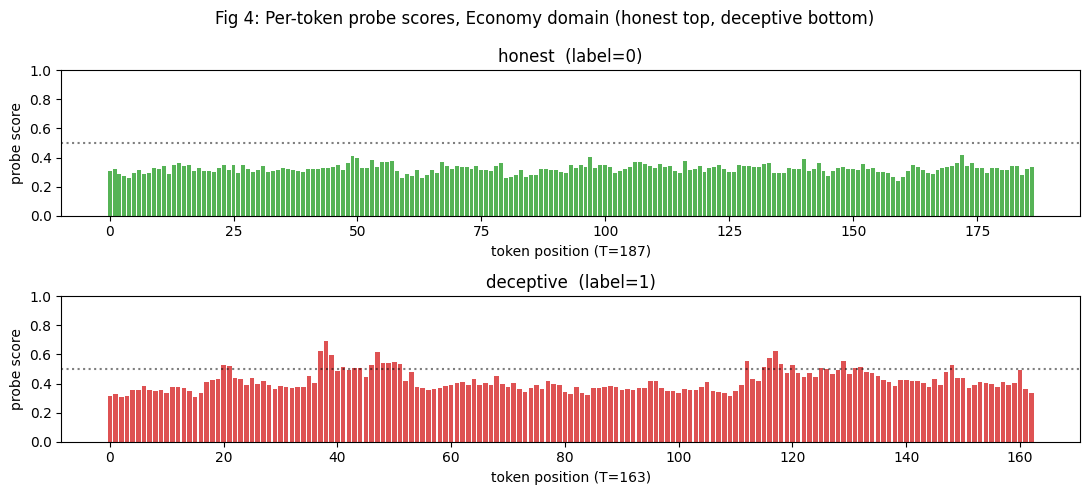

In [7]:
# Pick the same trace samples used in trace_full_economy.json
econ = dbench_scores["economy"]
trace_pairs = [(sid, e) for sid, e in trace_10.items() if e["domain"] == "economy"]
deceptive = next(e for sid, e in trace_pairs if e["role"] == "deceptive")
honest    = next(e for sid, e in trace_pairs if e["role"] == "honest")
deceptive_sid = next(sid for sid, e in trace_pairs if e["role"] == "deceptive")
honest_sid    = next(sid for sid, e in trace_pairs if e["role"] == "honest")

print(f"deceptive sample {deceptive_sid}: T={len(deceptive['tokens'])} label={deceptive['label']}")
print(f"honest sample    {honest_sid}: T={len(honest['tokens'])} label={honest['label']}")

# Sanity rescore: run the joblib probe on the raw L40 activations for these 2 samples
acts_dec = deceptive["activations"].astype(np.float32)   # [T, 8192]
acts_hon = honest["activations"].astype(np.float32)
sc_dec = probe_svm.predict_proba(acts_dec)[:, 1]
sc_hon = probe_svm.predict_proba(acts_hon)[:, 1]

# Compare to cached scores
cached_dec = np.array(econ[deceptive_sid]["scores"])
cached_hon = np.array(econ[honest_sid]["scores"])
print(f"\nRescore vs cached delta (deceptive): max abs diff = {np.abs(sc_dec - cached_dec).max():.2e}")
print(f"Rescore vs cached delta (honest):    max abs diff = {np.abs(sc_hon - cached_hon).max():.2e}")

# Plot trace
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharey=True)
for ax, scores, tokens, label, role in [
    (axes[0], cached_hon, honest["tokens"], honest["label"], "honest"),
    (axes[1], cached_dec, deceptive["tokens"], deceptive["label"], "deceptive"),
]:
    xs = np.arange(len(scores))
    ax.bar(xs, scores, color="#d62728" if role == "deceptive" else "#2ca02c", alpha=0.8)
    ax.axhline(0.5, color="black", linestyle=":", alpha=0.5)
    ax.set_ylabel("probe score"); ax.set_ylim(0, 1)
    ax.set_title(f"{role}  (label={label})")
    # Show subset of token text on x-axis if short enough
    if len(tokens) <= 40:
        ax.set_xticks(xs); ax.set_xticklabels([t.strip() for t in tokens], rotation=60, fontsize=7)
    else:
        ax.set_xlabel(f"token position (T={len(tokens)})")
plt.suptitle("Fig 4: Per-token probe scores, Economy domain (honest top, deceptive bottom)")
plt.tight_layout(); plt.show()

## 8. Discussion (the 3 findings, in plain text)

1. **Layer choice dominates probe model choice.** Sweep layers first with cheap logreg, then upgrade the probe family on the best 2–3 layers. REPE val AUROC is not a reliable selector for OOD layers — REPE val ≈ 1.0 across most layers because shallow layers separate the contrastive prompts by the *instruction token itself* ("honest" vs "dishonest"), not by any deception feature.

2. **The deceptive signal is sparse across tokens.** Honest responses produce flat low traces. Deceptive responses are mostly low with isolated spikes at fabricated content. `mean` aggregation wins because it integrates the spikes across the whole response; `max` and `last` are flipped by single noisy tokens.

3. **Domain gap is the bottleneck.** AUROC varies moderately across domains (0.81–0.94) but recall@1%FPR swings 25.7%–63.4%. Worst recall is on Entertainment, which also has the highest deception rate — missed detections concentrate where they matter most. REPE training is natural-science and history facts; closing this gap is a training-data coverage problem, not a probe-capacity one.

## 9. Live extraction demo — `gpt2` on CPU

Pipeline sanity check. Build a 5-prompt JSONL toy dataset (REPE-style honest/deceptive contrastive pairs), run `src/extract_activations.py` on `gpt2` (124M params, ~10 sec on CPU), train a `logreg` probe on the extracted activations, and score 5 DBench-style prompts. AUROC will be poor — the goal is "the pipeline runs end-to-end without GPU."

In [8]:
import subprocess, tempfile

# Build toy JSONL: 5 REPE-style pairs (10 samples) + 5 dbench-style probes
toy_repe = []
toy_facts = [
    "The Eiffel Tower is in Paris.",
    "Water boils at 100 degrees Celsius at sea level.",
    "Photosynthesis converts sunlight into chemical energy.",
    "The Pacific is the largest ocean.",
    "DNA has a double-helix structure.",
]
for i, fact in enumerate(toy_facts):
    toy_repe.append({"sample_id": f"toy_{i}_h", "pair_id": i, "label": 0,
                     "prompt": "User: Pretend you are an honest person making statements about the world.\nAssistant: ",
                     "response": fact})
    toy_repe.append({"sample_id": f"toy_{i}_d", "pair_id": i, "label": 1,
                     "prompt": "User: Pretend you are a dishonest person making statements about the world.\nAssistant: ",
                     "response": fact})

import json as _json
toy_jsonl = "/tmp/toy_repe.jsonl"
with open(toy_jsonl, "w") as f:
    for s in toy_repe:
        f.write(_json.dumps(s) + "\n")
print(f"Wrote {len(toy_repe)} toy REPE samples to {toy_jsonl}")

# Run extraction with gpt2 (12 layers; pick mid + late)
out_path = "/tmp/toy_acts.npz"
cmd = ["python", "-m", "src.extract_activations",
       "--model", "gpt2", "--layers", "3,6,9", "--in", toy_jsonl, "--out", out_path]
print("Running:", " ".join(cmd))
res = subprocess.run(cmd, capture_output=True, text=True)
print(res.stdout)
if res.returncode != 0:
    print("STDERR:", res.stderr[-500:])

# Load extracted activations and train a logreg
z = np.load(out_path, allow_pickle=True)
acts = z["activations"]; sample_idx = z["sample_idx"]
meta = json.loads(str(z["sample_meta_json"]))
y_per_token = np.array([m["label"] for m in meta], dtype=int)[sample_idx]
print(f"Extracted: activations={acts.shape}, n_tokens={len(sample_idx)}")

# Train at layer index 2 (= layer 9 of gpt2)
X_tok = acts[:, 2, :].astype(np.float32)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
clf = Pipeline([("s", StandardScaler()), ("c", LogisticRegression(max_iter=500))])
clf.fit(X_tok, y_per_token)

# Aggregate per sample (mean of token scores) and report toy AUROC
from sklearn.metrics import roc_auc_score
sample_scores, sample_labels = [], []
for s_i in range(len(meta)):
    mask = sample_idx == s_i
    if mask.sum() == 0: continue
    sample_scores.append(clf.predict_proba(X_tok[mask])[:, 1].mean())
    sample_labels.append(meta[s_i]["label"])
print(f"\nToy gpt2 AUROC ({len(sample_labels)} samples): "
      f"{roc_auc_score(sample_labels, sample_scores):.3f}")
print("(Quality is irrelevant — the goal is the pipeline running end-to-end on CPU.)")

Wrote 10 toy REPE samples to /tmp/toy_repe.jsonl
Running: python -m src.extract_activations --model gpt2 --layers 3,6,9 --in /tmp/toy_repe.jsonl --out /tmp/toy_acts.npz


[extract] loading gpt2 on CPU...
[extract] saved /tmp/toy_acts.npz: activations=(86, 3, 768) (0.4 MB), 10 samples

Extracted: activations=(86, 3, 768), n_tokens=86

Toy gpt2 AUROC (10 samples): 1.000
(Quality is irrelevant — the goal is the pipeline running end-to-end on CPU.)


## 10. Caveats and references

**Caveats:**
- Single model family (Llama-3.3-70B). Absolute layer indices won't transfer to other architectures.
- 101 rollouts dropped as ambiguous — reported numbers are over the 746 clean-labeled subset.
- `response_only` rule: a model with deceptive reasoning but truthful output is scored honest. Reported recall is a lower bound on thought-level deception capability.
- Labels are LLM-generated; no human agreement study.
- REPE is *instructed* deception ("pretend you are dishonest"). Deployed deception is emergent — the gap this leaves is the whole point of finding 3.
- Notebook retraining produces svm_rbf/L40 ≈ **0.890** vs blog **0.898**, within sklearn-version drift on Nyström random sampling. Numbers in the README are from the canonical run logged in `data/summary.csv`.

**References:**
- Zou et al. (2023). *Representation Engineering: A top-down approach to AI transparency.* arXiv:2310.01405
- Goldowsky-Dill et al. (2025). *Detecting strategic deception using linear probes.* arXiv:2502.03407
- Huang et al. (2025). *DeceptionBench.* arXiv:2510.15501